In [26]:
options(java.parameters = "-Xmx64g")

library(HeatStress)
library(loadeR)
library(transformeR)
library(visualizeR)
library(RColorBrewer)
library(Kendall)
library(trend)
library(convertR)

source("functions_humidity.R")

Overview

This notebook provides a reproducible example of part of the workflow used in *Heat stress conditions in southern South America: characterization and long-term changes under observational uncertainty* 

The example illustrates:

(1) loading daily ERA5 data from the climate4R repository,

(2) deriving specific humidity (SH) and relative humidity (RH),

(3) calculating selected heat stress indices,

(4) estimating P90 and P99 thresholds for the 1991--2020 baseline period,

(5) computing annual aggregates and linear trends.

To keep the example computationally light, the analysis is restricted to a small region near Porto Alegre and to the warm season (DJF).


**Helper functions**

In [27]:

fP90 <- function(x) {
  as.numeric(quantile(x, probs = 0.90, na.rm = TRUE))
}

fP99 <- function(x) {
  as.numeric(quantile(x, probs = 0.99, na.rm = TRUE))
}

my.sum <- function(x) {
  sum(x, na.rm = TRUE)
}

my.sum <- function(x) ifelse( !all(is.na(x)), sum(x, na.rm=T), NA)

calc_index <- function(tas_grid, hurs_grid, fun) {
  tas  <- as.vector(tas_grid$Data)
  hurs <- as.vector(hurs_grid$Data)

  out_vals <- fun(tas, hurs = hurs)

  out <- hurs_grid
  out$Data <- array(out_vals, dim = dim(hurs_grid$Data))
  attributes(out$Data) <- attributes(tas_grid$Data)

  out
}

calc_swbgt     <- function(tas, hurs) calc_index(tas, hurs, swbgt)
calc_wbt       <- function(tas, hurs) calc_index(tas, hurs, wbt.Stull)
calc_hi        <- function(tas, hurs) calc_index(tas, hurs, hi)
calc_humidex   <- function(tas, hurs) calc_index(tas, hurs, humidex)
calc_discomInd <- function(tas, hurs) calc_index(tas, hurs, discomInd)

make_exceedance_P90 <- function(idx_DJF, idx_P90) {
  X <- idx_DJF$Data
  P <- idx_P90$Data[1, , ]

  nt <- dim(X)[1]
  out <- array(NA_real_, dim = dim(X))

  for (t in seq_len(nt)) {
    Xt <- X[t, , ]
    out[t, , ] <- ifelse(is.na(Xt), NA_real_, as.numeric(Xt > P))
  }

  res <- idx_DJF
  res$Data <- out
  attributes(res$Data) <- attributes(idx_DJF$Data)
  res
}

trend_fun <- function(x, anios) {
  ok <- is.finite(x) & is.finite(anios)
  if (sum(ok) < 3) return(c(NA_real_, NA_real_))

  slope <- coef(lm(x[ok] ~ anios[ok]))[2]
  pval  <- mk.test(x[ok], continuity = TRUE)$p.value

  c(slope, pval)
}

In [28]:
ls()

[1] "anios"                   "calc_discomInd"         
 [3] "calc_hi"                 "calc_humidex"           
 [5] "calc_index"              "calc_swbgt"             
 [7] "calc_wbt"                "coordenadas"            
 [9] "d2m"                     "Data"                   
[11] "Dataset"                 "discomInd_DJF"          
[13] "fP90"                    "fP99"                   
[15] "Grafico_ERA5_DJF"        "hi_DJF"                 
[17] "humidex_DJF"             "huss2hurs"              
[19] "i"                       "j"                      
[21] "make_exceedance_P90"     "matriz_pvalue_swbgt"    
[23] "matriz_pvalue_wbt"       "matriz_pvalueRH"        
[25] "matriz_pvalueSH"         "matriz_pvalueST"        
[27] "matriz_tendencias_swbgt" "matriz_tendencias_wbt"  
[29] "matriz_tendenciasRH"     "matriz_tendenciasSH"    
[31] "matriz_tendenciasST"     "my.sum"                 
[33] "res"                     "RH"                     
[35] "RH_DFJ_y"                "SH"                     
[37] "SH_DFJ_y"                "sp"                     
[39] "swbgt_DJF"               "swbgt_P90"              
[41] "swbgt_P99"               "swbgt_y"                
[43] "t2max"                   "tas2ws"                 
[45] "tdps2huss"               "trend_fun"              
[47] "TX_DFJ_y"                "variables"              
[49] "vector_RH"               "vector_SH"              
[51] "vector_swbgt"            "vector_TX"              
[53] "vector_wbt"              "wbt_DJF"                
[55] "wbt_P90"                 "wbt_P99"                
[57] "wbt_y"

**Data access**

ERA5 daily data are accessed from the climate4R repository.
Only a small region near Porto Alegre is used here to provide a lightweight example.

In [ ]:
df  <- read.csv("https://data.meteo.unican.es/inventory.csv")
sub <- subset(df, activity == "ERA5")
inv <- dataInventory(as.character(sub$location))

d2m <- loadGridData(
  as.character(sub$location),
  var = "d2m",
  years = 1982:2022,
  lonLim = c(-51.25, -51),
  latLim = c(-30, -31),
  season = c(12, 1, 2)
)

t2max <- loadGridData(
  as.character(sub$location),
  var = "t2mx",
  years = 1982:2022,
  lonLim = c(-51.25, -51),
  latLim = c(-30, -31),
  season = c(12, 1, 2)
)

sp <- loadGridData(
  as.character(sub$location),
  var = "sp",
  years = 1982:2022,
  lonLim = c(-51.25, -51),
  latLim = c(-30, -31),
  season = c(12, 1, 2)
)
 save(d2m, t2max, sp, file = "data/era5_example_objects.RData")
#or the complete domain is in data/era5_example_objects.RData

In [34]:
load('era5_example_objects.rda')

**Humidity variables**

Specific humidity (SH) is estimated from dew point temperature and surface pressure using the Bohren formulation. Relative humidity (RH) is then derived from SH, air temperature, and pressure.


In [35]:
SH <- tdps2huss(tdps = d2m, ps = sp, formula = "bohren")
RH <- huss2hurs(huss = SH, tas = t2max, ps = sp)

t2max <- gridArithmetics(t2max, 273, operator = "-")
gc()

[2026-03-17 12:49:08.003956] Converting tdps units ...

[2026-03-17 12:49:26.249869] Calculating specific humidity from dew point ...

[2026-03-17 12:49:54.33081] Done.

[2026-03-17 12:50:12.985961] Calculating Relative humidity ...

[2026-03-17 12:53:54.442433] Done.



,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,1661829,88.8,4071078,217.5,4071078,217.5
Vcells,444121263,3388.4,1519218972,11590.8,1899023714,14488.5


[2026-03-17 12:57:15.076668] - Computing climatology...

[2026-03-17 12:57:17.077211] - Done.



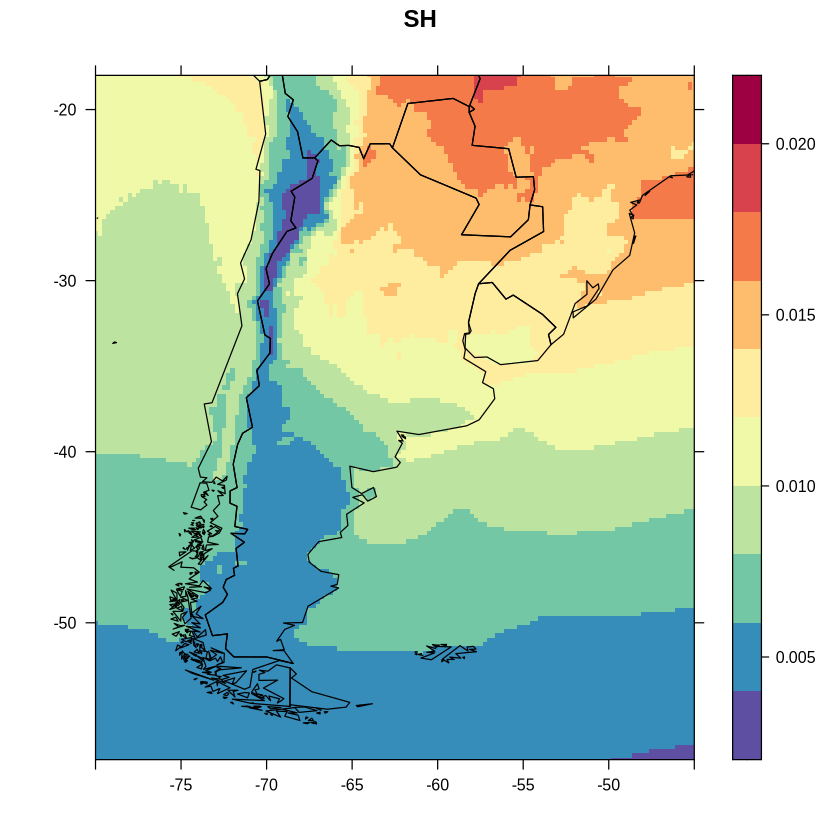

In [36]:
spatialPlot(climatology(SH),color.theme = "Spectral",set.max=0.022,set.min = 0.002,
            at=seq(0.002,0.022,0.002),
            scales = list(draw = TRUE),backdrop.theme = 'countries',
            main= "SH",rev.colors = T,xlim=c(-80,-45),ylim=c(-58,-18))

**Heat stress indices**

In [37]:
swbgt_DJF     <- calc_swbgt(t2max, RH)
humidex_DJF   <- calc_humidex(t2max, RH)
hi_DJF        <- calc_hi(t2max, RH)
discomInd_DJF <- calc_discomInd(t2max, RH)
wbt_DJF       <- calc_wbt(t2max, RH)
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,1661753,88.8,4071078,217.5,4071078,217.5
Vcells,884967755,6751.8,1823142766,13909.5,1899023714,14488.5


**Percentile thresholds (1991--2020)**

In [38]:
swbgt_P90     <- climatology(subsetGrid(swbgt_DJF, years = 1991:2020), clim.fun = list(FUN = "fP90"))
swbgt_P99     <- climatology(subsetGrid(swbgt_DJF, years = 1991:2020), clim.fun = list(FUN = "fP99"))

wbt_P90       <- climatology(subsetGrid(wbt_DJF, years = 1991:2020), clim.fun = list(FUN = "fP90"))
wbt_P99       <- climatology(subsetGrid(wbt_DJF, years = 1991:2020), clim.fun = list(FUN = "fP99"))

[2026-03-17 13:03:57.253765] - Computing climatology...

[2026-03-17 13:04:03.241425] - Done.

[2026-03-17 13:04:09.323225] - Computing climatology...

[2026-03-17 13:04:14.714105] - Done.

[2026-03-17 13:04:22.231233] - Computing climatology...

[2026-03-17 13:04:27.638069] - Done.

[2026-03-17 13:04:34.275764] - Computing climatology...

[2026-03-17 13:04:39.712652] - Done.



**Example: P90 exceedance counts**

In [39]:
datos_P90_wbt   <- make_exceedance_P90(wbt_DJF, wbt_P90)
nro_dias_P90_wbt <- aggregateGrid(datos_P90_wbt, aggr.y = list(FUN = my.sum))

dim(nro_dias_P90_wbt$Data)


[2026-03-17 13:05:17.583661] Performing annual aggregation...

[2026-03-17 13:05:26.392059] Done.



[1]  41 169 141

pad applied on the interval: year



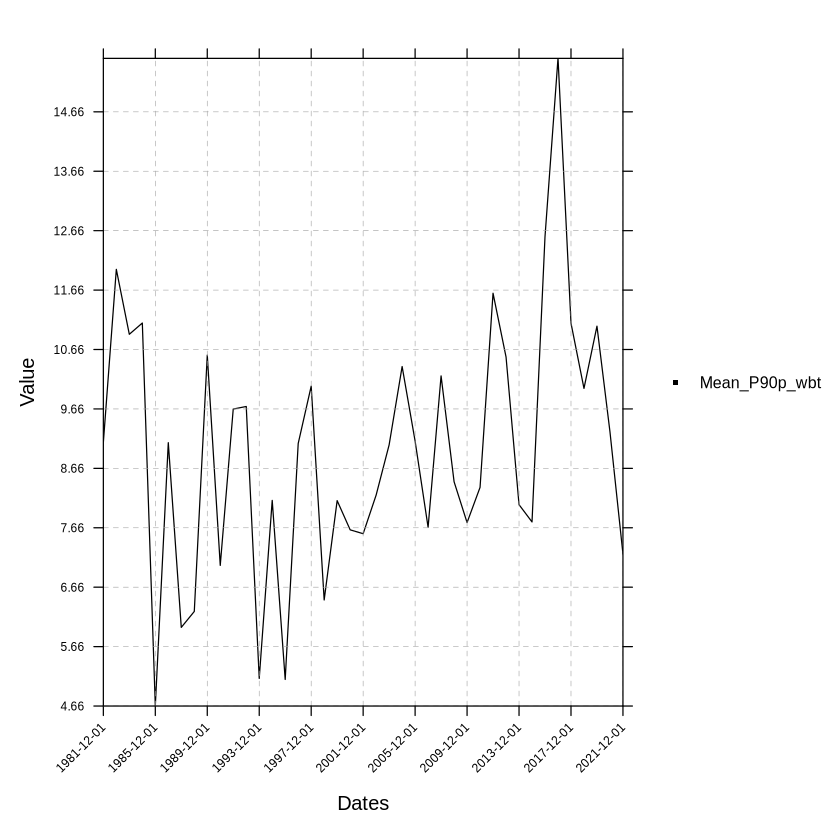

In [42]:
temporalPlot('Mean_P90p_wbt'=nro_dias_P90_wbt)

**Seasonal annual means**

In [41]:
TX_DFJ_y <- aggregateGrid(t2max,     aggr.y = list(FUN = "mean", na.rm = TRUE))
RH_DFJ_y <- aggregateGrid(RH,        aggr.y = list(FUN = "mean", na.rm = TRUE))
SH_DFJ_y <- aggregateGrid(SH,        aggr.y = list(FUN = "mean", na.rm = TRUE))
swbgt_y  <- aggregateGrid(swbgt_DJF, aggr.y = list(FUN = "mean", na.rm = TRUE))
wbt_y    <- aggregateGrid(wbt_DJF,   aggr.y = list(FUN = "mean", na.rm = TRUE))

gc()


[2026-03-17 13:06:43.73371] Performing annual aggregation...

[2026-03-17 13:06:57.078533] Done.

[2026-03-17 13:06:58.487543] Performing annual aggregation...

[2026-03-17 13:07:11.120399] Done.

[2026-03-17 13:07:11.883661] Performing annual aggregation...

[2026-03-17 13:07:23.997922] Done.

[2026-03-17 13:07:24.621371] Performing annual aggregation...

[2026-03-17 13:07:38.315665] Done.

[2026-03-17 13:07:38.921937] Performing annual aggregation...

[2026-03-17 13:07:53.006782] Done.



,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,1733756,92.6,4071081,217.5,4071081,217.5
Vcells,980007715,7476.9,1853160762,14138.5,1899023714,14488.5


**Trend estimation**
Linear trends are estimated from the annual DJF means, and Mann--Kendall is used to assess significance.

In [43]:
anios <- 1:41 #1982:2022

matriz_tendenciasST     <- matrix(NA, nrow = dim(RH_DFJ_y$Data)[2], ncol = dim(RH_DFJ_y$Data)[3])
matriz_pvalueST         <- matrix(NA, nrow = dim(RH_DFJ_y$Data)[2], ncol = dim(RH_DFJ_y$Data)[3])

matriz_tendenciasRH     <- matrix(NA, nrow = dim(RH_DFJ_y$Data)[2], ncol = dim(RH_DFJ_y$Data)[3])
matriz_pvalueRH         <- matrix(NA, nrow = dim(RH_DFJ_y$Data)[2], ncol = dim(RH_DFJ_y$Data)[3])

matriz_tendenciasSH     <- matrix(NA, nrow = dim(RH_DFJ_y$Data)[2], ncol = dim(RH_DFJ_y$Data)[3])
matriz_pvalueSH         <- matrix(NA, nrow = dim(RH_DFJ_y$Data)[2], ncol = dim(RH_DFJ_y$Data)[3])

matriz_tendencias_swbgt <- matrix(NA, nrow = dim(RH_DFJ_y$Data)[2], ncol = dim(RH_DFJ_y$Data)[3])
matriz_pvalue_swbgt     <- matrix(NA, nrow = dim(RH_DFJ_y$Data)[2], ncol = dim(RH_DFJ_y$Data)[3])

matriz_tendencias_wbt   <- matrix(NA, nrow = dim(RH_DFJ_y$Data)[2], ncol = dim(RH_DFJ_y$Data)[3])
matriz_pvalue_wbt       <- matrix(NA, nrow = dim(RH_DFJ_y$Data)[2], ncol = dim(RH_DFJ_y$Data)[3])

for (i in 1:dim(TX_DFJ_y$Data)[2]) {
  for (j in 1:dim(TX_DFJ_y$Data)[3]) {

    if (all(is.na(TX_DFJ_y$Data[, i, j]))) next

    vector_TX    <- TX_DFJ_y$Data[, i, j]
    vector_RH    <- RH_DFJ_y$Data[, i, j]
    vector_SH    <- SH_DFJ_y$Data[, i, j]
    vector_swbgt <- swbgt_y$Data[, i, j]
    vector_wbt   <- wbt_y$Data[, i, j]

    res <- trend_fun(vector_TX, anios)
    matriz_tendenciasST[i, j] <- res[1]
    matriz_pvalueST[i, j]     <- res[2]

    res <- trend_fun(vector_RH, anios)
    matriz_tendenciasRH[i, j] <- res[1]
    matriz_pvalueRH[i, j]     <- res[2]

    res <- trend_fun(vector_swbgt, anios)
    matriz_tendencias_swbgt[i, j] <- res[1]
    matriz_pvalue_swbgt[i, j]     <- res[2]

    res <- trend_fun(vector_wbt, anios)
    matriz_tendencias_wbt[i, j] <- res[1]
    matriz_pvalue_wbt[i, j]     <- res[2]

    res <- trend_fun(vector_SH, anios)
    matriz_tendenciasSH[i, j] <- res[1]
    matriz_pvalueSH[i, j]     <- res[2]
  }
}

**Export results to a data frame**

In [46]:
coordenadas <- data.frame(
  Lon = rep(rep(t2max$xyCoords$x, length(t2max$xyCoords$y)), 5),
  Lat = rep(rep(t2max$xyCoords$y, each = length(t2max$xyCoords$x)), 5)
)

Data <- data.frame(
  Tau = c(
    as.vector(t(matriz_tendenciasST)),
    as.vector(t(matriz_tendenciasRH)),
    as.vector(t(matriz_tendencias_swbgt)),
    as.vector(t(matriz_tendencias_wbt)),
    as.vector(t(matriz_tendenciasSH))
  ),
  p.value = c(
    as.vector(t(matriz_pvalueST)),
    as.vector(t(matriz_pvalueRH)),
    as.vector(t(matriz_pvalue_swbgt)),
    as.vector(t(matriz_pvalue_wbt)),
    as.vector(t(matriz_pvalueSH))
  )
)

variables <- data.frame(
  Var = rep(
    c("TX", "RH", "swbgt", "wbt", "SH"),
    each = length(as.vector(t(matriz_tendenciasST)))
  )
)

Dataset <- data.frame(
  Dataset = rep("ERA5", length(variables$Var)),
  Season  = rep("DJF",  length(variables$Var))
)

Grafico_ERA5_DJF <- cbind(Data, coordenadas, variables, Dataset)

head(Grafico_ERA5_DJF)

,Tau,p.value,Lon,Lat,Var,Dataset,Season
,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
1,-0.01949254,0.008302709,-80.00,-60,TX,ERA5,DJF
2,-0.01923315,0.009470720,-79.75,-60,TX,ERA5,DJF
3,-0.01901376,0.009470720,-79.50,-60,TX,ERA5,DJF
4,-0.01867611,0.009470720,-79.25,-60,TX,ERA5,DJF
5,-0.01838028,0.010783113,-79.00,-60,TX,ERA5,DJF
6,-0.01815625,0.008869554,-78.75,-60,TX,ERA5,DJF


**Reproducibility information**

In [45]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.3 LTS

Matrix products: default
BLAS/LAPACK: /opt/conda/envs/climate4r/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8          LC_NUMERIC=C                 
 [3] LC_TIME=en_US.UTF-8           LC_COLLATE=en_US.UTF-8       
 [5] LC_MONETARY=en_US.UTF-8       LC_MESSAGES=en_US.UTF-8      
 [7] LC_PAPER=en_US.UTF-8          LC_NAME=en_US.UTF-8          
 [9] LC_ADDRESS=en_US.UTF-8        LC_TELEPHONE=en_US.UTF-8     
[11] LC_MEASUREMENT=en_US.UTF-8    LC_IDENTIFICATION=en_US.UTF-8

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] convertR_0.2.1      udunits2_0.13.2.1   trend_1.1.6        
 [4] Kendall_2.2.2       RColorBrewer_1.1-3  visualizeR_1.6.4   
 [7] transformeR_2.2.2   loadeR_1.8.1        climate4R.UDG_0.2.6
[10] load